## Import and Prepare Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/export_annotations.csv')

In [18]:
df.head()

,thread_id,Majority Decision,country
0,DSiKM6WEVCz,Inside,usa
1,DRPukA1EQce,Inside,usa
2,DQMqoqgkR2s,Inside,usa
3,DUoC5HZEf9u,Inside,usa
4,DP6imYIEZla,Inside,usa


In [23]:
df['country'].value_counts()

,count
country,
usa,251
germany,204


In [ ]:
df.rename(columns={'Majority Decision': 'label'}, inplace=True)

In [ ]:
df = df[~pd.isna(df['label'])]

In [ ]:
df['label'].value_counts()

,count
label,
Inside,211
Outside,122
NotApplicable,105
Unsure,11


In [ ]:
# Filtere "Unsure" raus

df = df[df['label'] != "Unsure"]

In [ ]:
df.head()

,thread_id,label,country
0,DSiKM6WEVCz,Inside,usa
1,DRPukA1EQce,Inside,usa
2,DQMqoqgkR2s,Inside,usa
3,DUoC5HZEf9u,Inside,usa
4,DP6imYIEZla,Inside,usa


In [11]:
!pip install -q openai backoff krippendorff

In [12]:
import os
from google.colab import userdata
import backoff
import openai

api_key = userdata.get('open_ai_key')


client = openai.OpenAI(
    api_key = api_key
)

In [ ]:
system_prompt = """
You are an expert analyst of social media imagery.
Your task is to classify the LOCATION depicted in Instagram images related to lifestyle / tradwife content.
Ignore any assumptions about the account, ideology, captions, or hashtags.
Work only with visible visual evidence in the image.

⸻
🧭 Task

Decide which one of the codes below best matches the setting shown.

Code            Definition (visual cues)

Inside          Any indoor physical space (e.g., kitchen, living room, bedroom, bathroom, dining room, church, café, shop, clearly visible interior architecture such as walls, ceilings, windows, furniture).

Outside         Any outdoor physical space (e.g., garden, yard, terrace, farm, street, park, field, playground, visible sky, vegetation, natural landscape, outdoor lighting).

NotApplicable   No real physical setting visible (e.g., meme, quote image, heavy graphic design, collage, fully blurred or artificial background, AI-style backdrop without clear spatial cues).

⸻
🧠 Reasoning

Work through these steps internally, then summarise briefly:

1. Identify dominant visual cues (architecture, walls, ceiling, sky, vegetation, lighting).
2. Determine whether these cues indicate indoor or outdoor space.
3. If no real physical environment is visible, choose NotApplicable.
4. If cues conflict, choose the dominant visual impression.
5. Output your answer.

⸻
🧾 Expected Output

Reply only with a valid JSON object:

{
  "explanation": "<concise summary of why this code fits>",
  "label": "<exact code from the table>"
}

• explanation ≈ 1–2 short sentences (plain text, no markdown).
• Use the exact casing shown above for label.
• Do not add extra keys, comments, or formatting.
"""


## Vorbereitung Bilder / Datensatz

In [ ]:
df['image'] = df['thread_id'].apply(lambda x: f"/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/RAW/Posts/{x}.jpg")

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=4432,
        stratify=df["label"]
    )

In [ ]:
len(test_df)

88

In [ ]:
test_df.head()

,thread_id,label,country,image
273,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...
111,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...
382,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...
86,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...
355,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...


In [ ]:
test_df['label'].value_counts()

,count
label,
Inside,42
Outside,25
NotApplicable,21


## Zero-Shot

In [ ]:
from openai import OpenAI
import backoff

def run_few_shot_request(system_prompt, instruction_short, image=None, few_shot=None):
    messages = []

    if few_shot:
        messages.extend(few_shot)


    messages.append({"role": "user", "content": instruction_short})

    if image:
        messages.append({
            "role": "user",
            "content": [
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{image}"
                }
            ]
        })
    return client.responses.create(
        model="gpt-5-mini-2025-08-07",
        instructions=system_prompt,
        input=messages,
        reasoning={"effort": "medium"},
        text= {
            "format": { "type": "json_object" }
        }
    )

# Define instruction_short as it's used in the loop below
instruction_short = "Classify the location depicted in the image according to the provided categories. Respond with a JSON object."

In [ ]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [ ]:
import json
from tqdm.auto import tqdm
responses = []

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):

    image = encode_image(row['image'])
    response = run_few_shot_request(system_prompt, instruction_short, image)

    label = json.loads(response.output_text).get("label")
    explanation = json.loads(response.output_text).get("explanation")

    responses.append({
        **row,
        "GPT-5-mini": label,
        "Explanation": explanation
    })

  0%|          | 0/88 [00:00<?, ?it/s]

Let's inspect the actual filenames in the `/content/images` directory to understand their naming convention.

In [ ]:
!ls -l /content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/RAW/Posts| head -n 10

total 62355
-rw------- 1 root root  71448 Feb 14 19:09 B_i69ZDDALG.jpg
-rw------- 1 root root  58063 Feb 14 19:09 C00ARnnN4jo.jpg
-rw------- 1 root root  45878 Feb 14 19:09 C05GXjGNudX.jpg
-rw------- 1 root root  44277 Feb 14 19:09 C07s8Z4tL7b.jpg
-rw------- 1 root root  87380 Feb 14 19:09 C09UgTiNGrY.jpg
-rw------- 1 root root 105461 Feb 14 19:09 C0aGqobOm6X.jpg
-rw------- 1 root root  69676 Feb 14 19:09 C0H9XuCOxSw.jpg
-rw------- 1 root root  46214 Feb 14 19:09 C0jxf27upVC.jpg
-rw------- 1 root root  55167 Feb 14 19:09 C0Ki7oxOepO.jpg


This command will show the first 10 files in the `/content/images` directory. Please run this cell and let me know the output. This will help me determine the correct way to construct the image paths.

In [ ]:
responses_df = pd.DataFrame(responses)

In [ ]:
responses_df.head()

,thread_id,label,country,image,GPT-5-mini,Explanation
0,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open sky, hillside, vegetation, raised garden ..."
1,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible open sky, trees, and a large monument ..."
2,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open natural landscape with visible sky, grass..."
3,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible trees, sky, outdoor lantern, and surro..."
4,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,The scene clearly shows a kitchen interior wit...


In [ ]:
responses_df.to_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set.csv', index=False)

In [ ]:
import pandas as pd
responses_df = pd.read_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set.csv')

In [ ]:
responses_df.head()

,thread_id,label,country,image,GPT-5-mini,Explanation
0,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open sky, hillside, vegetation, raised garden ..."
1,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible open sky, trees, and a large monument ..."
2,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open natural landscape with visible sky, grass..."
3,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible trees, sky, outdoor lantern, and surro..."
4,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,The scene clearly shows a kitchen interior wit...


               precision    recall  f1-score   support

       Inside       0.86      1.00      0.92        42
NotApplicable       1.00      0.52      0.69        21
      Outside       0.89      1.00      0.94        25

     accuracy                           0.89        88
    macro avg       0.92      0.84      0.85        88
 weighted avg       0.90      0.89      0.87        88



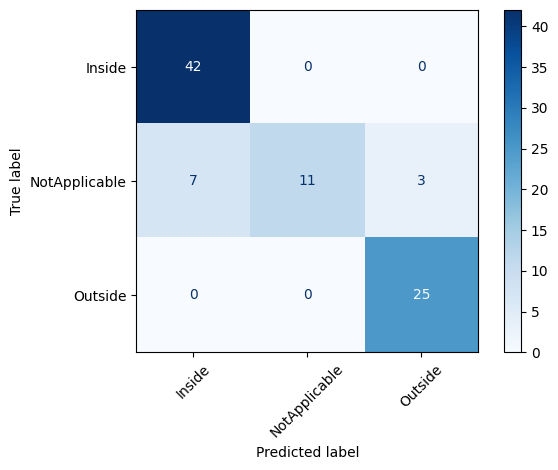

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Wahre und vorhergesagte Labels
true_labels = responses_df['label']
predicted_labels = responses_df['GPT-5-mini']

# Klassifikationsbericht anzeigen
report = classification_report(true_labels, predicted_labels)
print(report)

# Konfusionsmatrix erstellen
cm = confusion_matrix(true_labels, predicted_labels, labels=sorted(true_labels.unique()))

# Konfusionsmatrix anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(true_labels.unique()))
disp.plot(xticks_rotation=45, cmap='Blues')

# Plot anzeigen
plt.tight_layout()
plt.show()

In [ ]:
import krippendorff
import numpy as np

# Your two columns
human = responses_df['label'].tolist()
gpt = responses_df['GPT-5-mini'].tolist()


# Convert to a format compatible with krippendorff (list of raters per item)
data = [ [h, g] for h, g in zip(human, gpt) ]  # Each sublist = ratings by two coders

# Transpose to get raters as rows
matrix = np.array(data).T

# Calculate Krippendorff's alpha (nominal metric)
alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='nominal')
print(f"Krippendorff's alpha: {alpha:.3f}")

Krippendorff's alpha: 0.814


### Mini-Fehleranalyse

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

# False Negatives filtern: True Label = 'Yes', Prediction = 'False'
false_negatives = responses_df[responses_df['label'] != responses_df['GPT-5-mini']]

# Anzahl der Bilder und Grid-Größe bestimmen
num_images = len(false_negatives)
cols = 3
rows = math.ceil(num_images / cols)

# Plot erstellen
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# Sicherstellen, dass axes ein 2D-Array ist
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

# Bilder mit Labels einfügen
for idx, (_, row) in enumerate(false_negatives.iterrows()):
    row_idx = idx // cols
    col_idx = idx % cols
    ax = axes[row_idx][col_idx]
    try:
        img = mpimg.imread(row['image'])
        ax.imshow(img)
        ax.set_title(f"Human: {row['label']} | GPT: {row['GPT-5-mini']}")
        ax.axis('off')
    except Exception as e:
        ax.set_title("Fehler beim Laden")
        ax.axis('off')

# Leere Plots ausblenden
for idx in range(num_images, rows * cols):
    row_idx = idx // cols
    col_idx = idx % cols
    axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Few-Shot (Random, k=3)

In [ ]:
few_shot_prompt = []
few_shot_image_paths = {}
few_shot_image_path_list = []
labels = df['label'].unique()

for label in labels:

  few_shot_image_paths[label] = []

  few_shot_samples = train_df[train_df['label'] == label].sample(n=3, random_state=4466)

  few_shot_images = [{
      "type": "input_text",
      "text": f"{{ 'label': '{label}' , explanation: '...'}}"
    }]
  for index, row in few_shot_samples.iterrows():
    few_shot_image_paths[label].append(row['image'])
    few_shot_image_path_list.append(row['image'])

    image = encode_image(row['image'])

    few_shot_images.append({
        "type": "input_image",
        "image_url": f"data:image/jpeg;base64,{image}",
        "detail": "low"
    })

  few_shot_prompt.append({
      "role": "user",
      "content": few_shot_images
  })


In [ ]:
import json
from tqdm.auto import tqdm
responses = []

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):

    image = encode_image(row['image'])
    response = run_few_shot_request(system_prompt, instruction_short, image, few_shot=few_shot_prompt)

    label = json.loads(response.output_text).get("label")
    explanation = json.loads(response.output_text).get("explanation")

    responses.append({
        **row,
        "GPT-5-mini": label,
        "Explanation": explanation
    })

  0%|          | 0/88 [00:00<?, ?it/s]

In [ ]:
responses_df = pd.DataFrame(responses)

In [ ]:
responses_df.head()

,thread_id,label,country,image,GPT-5-mini,Explanation
0,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible sky, hillside, raised garden beds, flo..."
1,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open plaza with a large monument, visible sky,..."
2,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible open sky, grassy fields, trees, a fenc..."
3,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Trees, natural light, and an outdoor lamp with..."
4,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,"Visible kitchen cabinets, countertop, utensils..."


In [ ]:
responses_df.to_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set-Few-Shot.csv', index=False)

In [ ]:
import pandas as pd
responses_df = pd.read_csv('/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set-Few-Shot.csv')

In [ ]:
responses_df.head()

,thread_id,label,country,image,GPT-5-mini,Explanation
0,DPNrGbpEdDn,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible sky, hillside, raised garden beds, flo..."
1,CW8r5WQtSvb,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Open plaza with a large monument, visible sky,..."
2,CWYjX3kL2MI,Outside,germany,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Visible open sky, grassy fields, trees, a fenc..."
3,Cjgwbdasffh,Outside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Outside,"Trees, natural light, and an outdoor lamp with..."
4,DQWtJrGERvz,Inside,usa,/content/drive/MyDrive/Forschungsseminar_Compu...,Inside,"Visible kitchen cabinets, countertop, utensils..."


               precision    recall  f1-score   support

       Inside       0.86      1.00      0.92        42
NotApplicable       1.00      0.52      0.69        21
      Outside       0.89      1.00      0.94        25

     accuracy                           0.89        88
    macro avg       0.92      0.84      0.85        88
 weighted avg       0.90      0.89      0.87        88



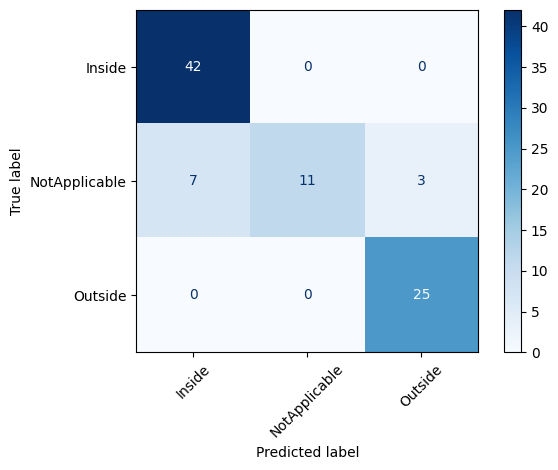

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Wahre und vorhergesagte Labels
true_labels = responses_df['label']
predicted_labels = responses_df['GPT-5-mini']

# Klassifikationsbericht anzeigen
report = classification_report(true_labels, predicted_labels)
print(report)

# Konfusionsmatrix erstellen
cm = confusion_matrix(true_labels, predicted_labels, labels=sorted(true_labels.unique()))

# Konfusionsmatrix anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(true_labels.unique()))
disp.plot(xticks_rotation=45, cmap='Blues')

# Plot anzeigen
plt.tight_layout()
plt.show()

In [ ]:
import krippendorff
import numpy as np

# Your two columns
human = responses_df['label'].tolist()
gpt = responses_df['GPT-5-mini'].tolist()


# Convert to a format compatible with krippendorff (list of raters per item)
data = [ [h, g] for h, g in zip(human, gpt) ]  # Each sublist = ratings by two coders

# Transpose to get raters as rows
matrix = np.array(data).T

# Calculate Krippendorff's alpha (nominal metric)
alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='nominal')
print(f"Krippendorff's alpha: {alpha:.3f}")

Krippendorff's alpha: 0.814


### Mini-Fehleranalyse

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

# False Negatives filtern: True Label = 'Yes', Prediction = 'False'
false_negatives = responses_df[responses_df['label'] != responses_df['GPT-5-mini']]

# Anzahl der Bilder und Grid-Größe bestimmen
num_images = len(false_negatives)
cols = 3
rows = math.ceil(num_images / cols)

# Plot erstellen
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# Sicherstellen, dass axes ein 2D-Array ist
if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

# Bilder mit Labels einfügen
for idx, (_, row) in enumerate(false_negatives.iterrows()):
    row_idx = idx // cols
    col_idx = idx % cols
    ax = axes[row_idx][col_idx]
    try:
        img = mpimg.imread(row['image'])
        ax.imshow(img)
        ax.set_title(f"Human: {row['label']} | GPT: {row['GPT-5-mini']}")
        ax.axis('off')
    except Exception as e:
        ax.set_title("Fehler beim Laden")
        ax.axis('off')

# Leere Plots ausblenden
for idx in range(num_images, rows * cols):
    row_idx = idx // cols
    col_idx = idx % cols
    axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Vergleich USA vs. Germany

In [9]:
# @title Import computational annotations
# @markdown Reading the GPT annotations. Enter the correct file path below

import pandas as pd
import numpy as np

annotated_file = '/content/drive/MyDrive/Forschungsseminar_Computergestützte_Analyse_Sozialer_Medien/Daten/Auswertung/GPT5-mini-Test-Set.csv' # @param {type:"string"}
coding_column = 'GPT-5-mini' # @param {type:"string"}
annotated_identifier = 'thread_id' # @param {type:"string"}

annotated_df = pd.read_csv(annotated_file)

Analyzing 46 entries for USA data after NaN removal.

Classification Report for USA data:
               precision    recall  f1-score   support

       Inside       0.83      1.00      0.91        24
NotApplicable       1.00      0.54      0.70        13
      Outside       0.90      1.00      0.95         9

     accuracy                           0.87        46
    macro avg       0.91      0.85      0.85        46
 weighted avg       0.89      0.87      0.86        46


Confusion Matrix for USA data:


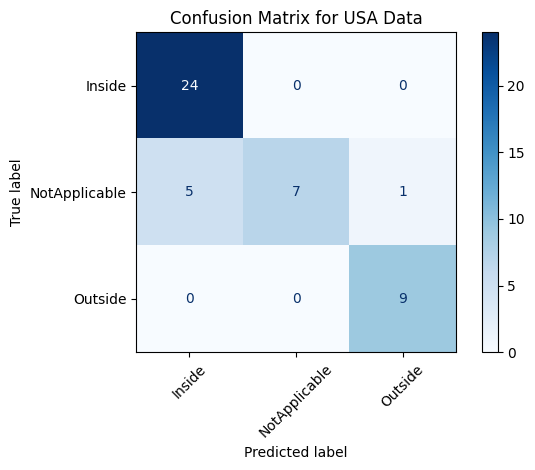


Krippendorff's alpha for USA data: 0.777


In [14]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import krippendorff
import numpy as np

# 1. Filter the annotated_df for 'usa' entries
usa_df = annotated_df[annotated_df['country'] == 'usa'].copy()

# 2. Drop rows with NaN values in 'label' or 'GPT-5-mini' columns
usa_df.dropna(subset=['label', 'GPT-5-mini'], inplace=True)

# 3. Extract true and predicted labels
true_labels_usa = usa_df['label']
predicted_labels_usa = usa_df['GPT-5-mini']

print(f"Analyzing {len(usa_df)} entries for USA data after NaN removal.\n")

# 4. Print the classification report
print("Classification Report for USA data:")
report_usa = classification_report(true_labels_usa, predicted_labels_usa)
print(report_usa)

# 5. Create and display a confusion matrix
print("\nConfusion Matrix for USA data:")
cm_usa = confusion_matrix(true_labels_usa, predicted_labels_usa, labels=sorted(true_labels_usa.unique()))
disp_usa = ConfusionMatrixDisplay(confusion_matrix=cm_usa, display_labels=sorted(true_labels_usa.unique()))
disp_usa.plot(xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix for USA Data')
plt.tight_layout()
plt.show()

# 6. Calculate and print Krippendorff's alpha
# Convert to a format compatible with krippendorff (list of raters per item)
data_usa = [ [h, g] for h, g in zip(true_labels_usa.tolist(), predicted_labels_usa.tolist()) ]
# Transpose to get raters as rows
matrix_usa = np.array(data_usa).T

# Calculate Krippendorff's alpha (nominal metric)
alpha_usa = krippendorff.alpha(reliability_data=matrix_usa, level_of_measurement='nominal')
print(f"\nKrippendorff's alpha for USA data: {alpha_usa:.3f}")

Analyzing 42 entries for Germany data after NaN removal.

Classification Report for Germany data:
               precision    recall  f1-score   support

       Inside       0.90      1.00      0.95        18
NotApplicable       1.00      0.50      0.67         8
      Outside       0.89      1.00      0.94        16

     accuracy                           0.90        42
    macro avg       0.93      0.83      0.85        42
 weighted avg       0.91      0.90      0.89        42



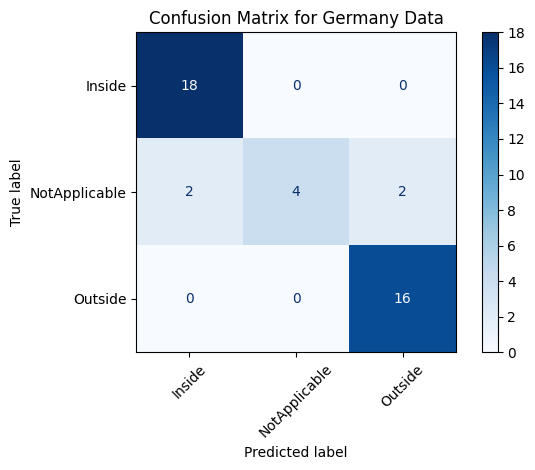


Krippendorff's alpha for Germany data: 0.846


In [16]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import krippendorff
import numpy as np

# 1. Filter the annotated_df for 'germany' entries
germany_df = annotated_df[annotated_df['country'] == 'germany'].copy()

# 2. Drop rows with NaN values in 'label' or 'GPT-5-mini' columns
germany_df.dropna(subset=['label', 'GPT-5-mini'], inplace=True)

# 3. Extract true and predicted labels
true_labels_germany = germany_df['label']
predicted_labels_germany = germany_df['GPT-5-mini']

# 4. Print a descriptive message
print(f"Analyzing {len(germany_df)} entries for Germany data after NaN removal.\n")

# 5. Print the classification report
print("Classification Report for Germany data:")
report_germany = classification_report(true_labels_germany, predicted_labels_germany)
print(report_germany)

# 6. Create a confusion matrix
cm_germany = confusion_matrix(true_labels_germany, predicted_labels_germany, labels=sorted(true_labels_germany.unique()))

# 7. Display the confusion matrix
disp_germany = ConfusionMatrixDisplay(confusion_matrix=cm_germany, display_labels=sorted(true_labels_germany.unique()))
disp_germany.plot(xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix for Germany Data')
plt.tight_layout()
plt.show()

# 8. Calculate Krippendorff's alpha
data_germany = [ [h, g] for h, g in zip(true_labels_germany.tolist(), predicted_labels_germany.tolist()) ]
matrix_germany = np.array(data_germany).T
alpha_germany = krippendorff.alpha(reliability_data=matrix_germany, level_of_measurement='nominal')
print(f"\nKrippendorff's alpha for Germany data: {alpha_germany:.3f}")

## Summary (von Gemini):

### Data Analysis Key Findings

*   **Analyzed Data Points**: For the USA dataset, 46 entries were analyzed after cleaning, while for Germany, 42 entries were analyzed.
*   **Overall Accuracy**: The 'GPT-5-mini' model achieved a slightly higher overall accuracy for Germany data (0.90) compared to USA data (0.87).
*   **Krippendorff's Alpha**: The agreement (Krippendorff's alpha) between the model's predictions and true labels was higher for Germany (0.846) than for the USA (0.777), indicating better reliability in Germany.
*   **Macro Average Performance**:
    *   Macro average precision was slightly higher for Germany (0.93) than for USA (0.91).
    *   Macro average recall was slightly higher for USA (0.85) than for Germany (0.83).
    *   The macro average F1-score was identical for both countries at 0.85.
*   **Class-specific Performance (F1-score)**:
    *   Both datasets showed the lowest F1-score for the 'NotApplicable' class (USA: 0.70, Germany: 0.67), suggesting this class is the most challenging for the model to predict accurately in both regions.
    *   The 'Inside' and 'Outside' classes generally showed strong performance, with F1-scores ranging from 0.91 to 0.95 across both countries.

### Insights or Next Steps

*   The model generally performs well in both regions, but there's a consistent challenge in classifying the 'NotApplicable' category. Further investigation into the characteristics of 'NotApplicable' images could help improve model performance for this specific class.
*   The higher Krippendorff's alpha and slightly better overall accuracy for Germany suggest that either the 'GPT-5-mini' model is marginally more robust for the German dataset's characteristics, or the labeling for German data might be more consistent. A detailed error analysis for both regions could reveal underlying reasons for these differences.
